In [49]:
from langgraph.graph import StateGraph, START, MessagesState
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

In [50]:
load_dotenv()

True

In [51]:
model = ChatOpenAI()

In [52]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [53]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

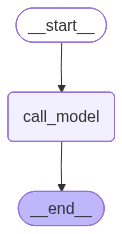

In [54]:
graph = builder.compile()
graph

In [55]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Ritik."}]})

{'messages': [HumanMessage(content='Hi! My name is Ritik.', additional_kwargs={}, response_metadata={}, id='42df83d7-d585-47b8-8940-447ff0c1574f'),
  AIMessage(content='Hello, Ritik! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 15, 'total_tokens': 27, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DjfGFXG2hLOkJWSbXMcUUneBSDMn0', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e62e6-946e-7921-bb6c-af307ea00ff6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 12, 'total_tokens': 27, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_to

In [56]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]})

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='130aa25a-68e8-4cb0-94e5-5d74a6437504'),
  AIMessage(content="I'm sorry, I can't determine your name as an AI assistant.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 12, 'total_tokens': 27, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DjfGGiGwJi7NzbGvhyjrkI6IIwfmI', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e62e6-9827-77d2-82b2-cd68d167706e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 15, 'total_tokens': 27, 'input_token_details': {'audio': 0, 'cache_read': 0}

In [57]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [58]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [59]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [60]:
config = {"configurable": {"thread_id": "thread-1"}}
config2 = {"configurable": {"thread_id": "thread-2"}}

In [61]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Ritik."}]}, config)

{'messages': [HumanMessage(content='Hi! My name is Ritik.', additional_kwargs={}, response_metadata={}, id='6733b549-68a6-4b93-b98a-25ec6c980250'),
  AIMessage(content='Hello Ritik! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 15, 'total_tokens': 26, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DjfGH36AZSsQ5lkUzRDKV75Xz4yG5', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e62e6-9c1a-7180-b99b-84c0eaacc9af-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 11, 'total_tokens': 26, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_tok

In [62]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]}, config)

{'messages': [HumanMessage(content='Hi! My name is Ritik.', additional_kwargs={}, response_metadata={}, id='6733b549-68a6-4b93-b98a-25ec6c980250'),
  AIMessage(content='Hello Ritik! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 15, 'total_tokens': 26, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DjfGH36AZSsQ5lkUzRDKV75Xz4yG5', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e62e6-9c1a-7180-b99b-84c0eaacc9af-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 11, 'total_tokens': 26, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_tok

In [63]:
snap = graph.get_state(config)
vals = snap.values
for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content)

- HumanMessage : Hi! My name is Ritik.
- AIMessage : Hello Ritik! How can I assist you today?
- HumanMessage : What is my name?
- AIMessage : Your name is Ritik.


In [64]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]}, config2)

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='9394f5a3-6e4f-4ee8-9bed-8f39d7aa520b'),
  AIMessage(content="I'm sorry, I do not know your name.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 12, 'total_tokens': 23, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DjfGJVxuahT7ZFcsVMEwMswJh9uOI', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e62e6-a4bb-73d1-802a-f8f122fbe0ee-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 11, 'total_tokens': 23, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details